<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=========== EDGE DEVICE ===========
Current Water Level : 44 %
Stored at Edge : 50

=========== CLOUD ===========
Cloud Records : 50
Mean : 54.68
Moving Average : 57.2
Standard Deviation : 26.92
Status : NORMAL


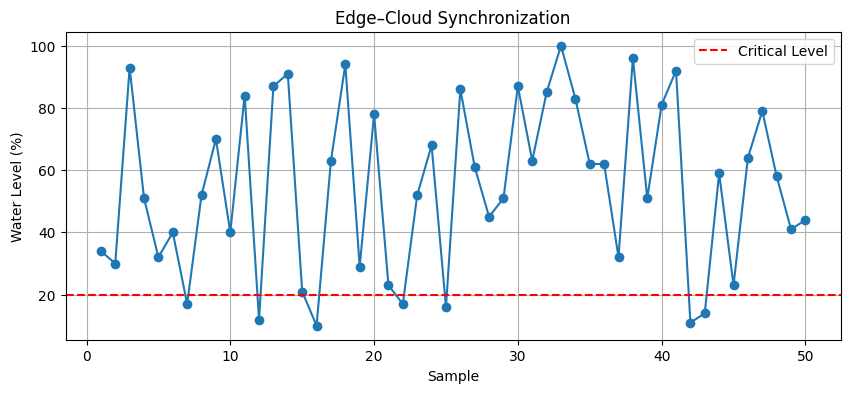

Experiment Completed Successfully


In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
edge_storage = []
cloud_storage = []
time_data = []
for i in range(1,51):
    water_level = random.randint(10,100)
    # Edge Storage
    edge_storage.append(water_level)
    # Synchronize to Cloud
    cloud_storage.append(water_level)
    time_data.append(i)
    mean = np.mean(cloud_storage)
    std = np.std(cloud_storage)
    if len(cloud_storage)>=5:
        moving=np.mean(cloud_storage[-5:])
    else:
        moving=mean
    if water_level<20:
        status="LOW WATER LEVEL"
    else:
        status="NORMAL"
    clear_output(wait=True)
    print("=========== EDGE DEVICE ===========")
    print("Current Water Level :",water_level,"%")
    print("Stored at Edge :",len(edge_storage))
    print()
    print("=========== CLOUD ===========")
    print("Cloud Records :",len(cloud_storage))
    print("Mean :",round(mean,2))

    print("Moving Average :",round(moving,2))
    print("Standard Deviation :",round(std,2))
    print("Status :",status)
    plt.figure(figsize=(10,4))
    plt.plot(time_data,cloud_storage,marker='o')
    plt.axhline(20,color='red',linestyle='--',label='Critical Level')
    plt.xlabel("Sample")
    plt.ylabel("Water Level (%)")
    plt.title("Edge–Cloud Synchronization")
    plt.legend()
    plt.grid(True)
    plt.show()
    time.sleep(0.5)
df=pd.DataFrame({
    "Sample":time_data,
    "Water Level":cloud_storage
})
df.to_csv("cloud_water_data.csv",index=False)
print("Experiment Completed Successfully")
